In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/starbucks_customer_ordering.csv')
print("Размер:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о типах и пропусках:")
df.info()
print("\nСтатистика числовых столбцов:")
display(df.describe())

Размер: (100000, 20)

Первые 5 строк:


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3



Информация о типах и пропусках:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  str    
 1   order_id               100000 non-null  str    
 2   order_date             100000 non-null  str    
 3   order_time             100000 non-null  str    
 4   day_of_week            100000 non-null  str    
 5   order_channel          100000 non-null  str    
 6   store_id               100000 non-null  str    
 7   store_location_type    100000 non-null  str    
 8   region                 100000 non-null  str    
 9   customer_age_group     100000 non-null  str    
 10  customer_gender        100000 non-null  str    
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend    

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,3.741510,1.81077,14.866771,4.546080,3.687530
std,1.697817,1.46280,5.506800,1.550269,1.184123
min,1.000000,0.00000,3.510000,1.000000,1.000000
25%,3.000000,1.00000,10.837500,3.400000,3.000000
50%,4.000000,2.00000,14.170000,4.400000,4.000000
75%,5.000000,3.00000,18.180000,5.500000,5.000000
max,10.000000,8.00000,40.310000,11.200000,5.000000


In [94]:
# Проверка пропусков
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_table = pd.DataFrame({'missing': missing, '%': missing_pct})
print(missing_table[missing_table['missing'] > 0])

Empty DataFrame
Columns: [missing, %]
Index: []


In [95]:
dups = df.duplicated().sum()
print(f"Дубликаты: {dups}")
if dups > 0:
    df = df.drop_duplicates()

Дубликаты: 0


In [96]:
# ----- 2.1 Выбросы -----
# Идентифицируем целевую переменную – предположим, она называется 'total_spent'
target_col = 'total_spend'  
if target_col not in df.columns:
    # поищем похожие названия
    possible_targets = [col for col in df.columns if 'total' in col.lower() or 'spend' in col.lower() or 'amount' in col.lower()]
    if possible_targets:
        target_col = possible_targets[0]
        print(f"Целевая переменная предположительно: {target_col}")
    else:
        raise ValueError("Не удалось определить целевую переменную. Укажите вручную.")

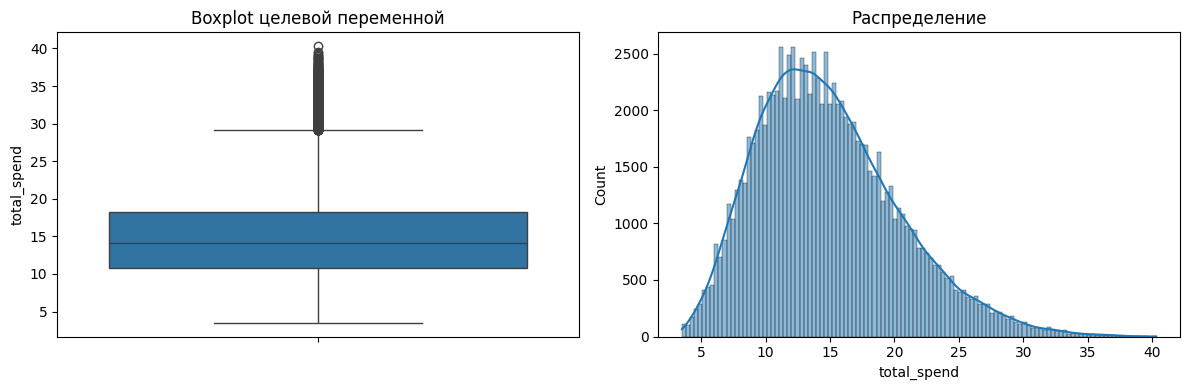

In [97]:
# Визуализация выбросов
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(y=df[target_col], ax=axes[0])
axes[0].set_title('Boxplot целевой переменной')
sns.histplot(df[target_col], kde=True, ax=axes[1])
axes[1].set_title('Распределение')
plt.tight_layout()
plt.show()

# Применяем логарифмическое преобразование (уменьшает влияние выбросов)
df['total_spent_log'] = np.log1p(df[target_col])

In [98]:
# order_date в datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# order_time оставляем как строку (формат HH:MM)
# Убедимся, что это строка
df['order_time'] = df['order_time'].astype(str)

# day_of_week преобразуем в числа (Mon=0, Tue=1, ...)
day_map = {'Mon':0, 'Tue':1, 'Wed':2, 'Thu':3, 'Fri':4, 'Sat':5, 'Sun':6}
df['day_of_week_num'] = df['day_of_week'].map(day_map)

# Категориальные признаки -> category
cat_cols = ['order_channel', 'store_location_type', 'region', 
            'customer_age_group', 'customer_gender', 'drink_category']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Логические столбцы -> bool
bool_cols = ['is_rewards_member', 'has_food_item', 'order_ahead']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)

In [99]:
# Feature Engineering (новые признаки)
# Безопасное извлечение часа из order_time
def extract_hour_from_time_str(s):
    try:
        s = str(s).strip()
        if not s:
            return 12
        if ':' in s:
            return int(s.split(':')[0])
        else:
            return int(float(s))
    except:
        return 12

df['hour'] = df['order_time'].apply(extract_hour_from_time_str)

# Защита от NaN
if df['hour'].isnull().any():
    print("Обнаружены NaN в hour, заполняем медианой")
    df['hour'].fillna(df['hour'].median(), inplace=True)

df['hour'] = df['hour'].astype(int)
df['order_time'] = df['hour']

# Категория времени суток
def time_period(h):
    if 5 <= h < 12:
        return 'morning'
    elif 12 <= h < 17:
        return 'afternoon'
    elif 17 <= h < 21:
        return 'evening'
    else:
        return 'night'
df['time_period'] = df['hour'].apply(time_period).astype('category')

# Месяц и день из order_date
df['month'] = df['order_date'].dt.month
df['day_of_month'] = df['order_date'].dt.day

# Выходной (если day_of_week >= 5)
df['is_weekend'] = (df['day_of_week_num'] >= 5).astype(int)

# Средняя цена за товар
if 'cart_size' in df.columns and 'total_spend' in df.columns:
    df['avg_item_price'] = df['total_spend'] / df['cart_size']
    df['avg_item_price'].fillna(df['total_spend'], inplace=True)

# Количество кастомизаций на один товар
if 'num_customizations' in df.columns and 'cart_size' in df.columns:
    df['custom_per_item'] = df['num_customizations'] / df['cart_size']
    df['custom_per_item'].fillna(0, inplace=True)

/var/folders/t9/w50p8w0917b0t61ks_6y_3g40000gn/T/ipykernel_23096/3195130686.py:47: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['avg_item_price'].fillna(df['total_spend'], inplace=True)
/var/folders/t9/w50p8w0917b0t61ks_6y_3g40000gn/T/ipykernel_23096/3195130686.py:52: ChainedAssignmentError: A value is being set on a copy of a Da

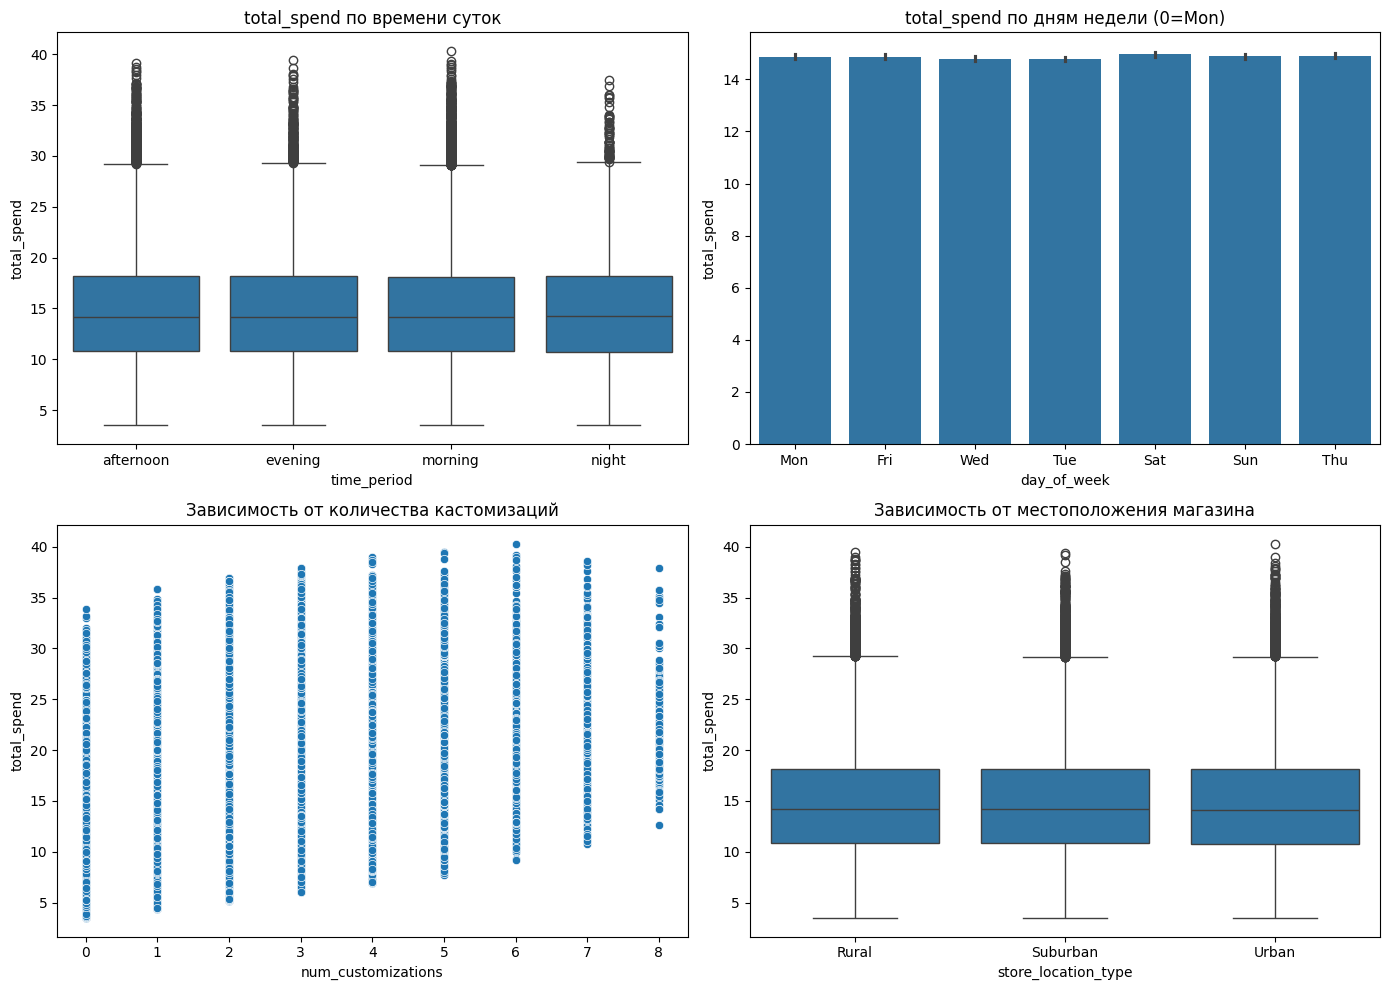

In [100]:
# Визуализации зависимостей
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Время суток vs total_spend
if 'time_period' in df.columns:
    sns.boxplot(data=df, x='time_period', y=target_col, ax=axes[0,0])
    axes[0,0].set_title(f'{target_col} по времени суток')

# День недели (числовой) vs total_spend
if 'day_of_week' in df.columns:
    sns.barplot(data=df, x='day_of_week', y=target_col, ax=axes[0,1])
    axes[0,1].set_title(f'{target_col} по дням недели (0=Mon)')

# Количество кастомизаций vs total_spend
if 'num_customizations' in df.columns:
    sns.scatterplot(data=df, x='num_customizations', y=target_col, ax=axes[1,0])
    axes[1,0].set_title('Зависимость от количества кастомизаций')

# Тип локации vs total_spend
if 'store_location_type' in df.columns:
    sns.boxplot(data=df, x='store_location_type', y=target_col, ax=axes[1,1])
    axes[1,1].set_title('Зависимость от местоположения магазина')

plt.tight_layout()
plt.savefig('../presentation/dependencies.png', dpi=100)
plt.show()

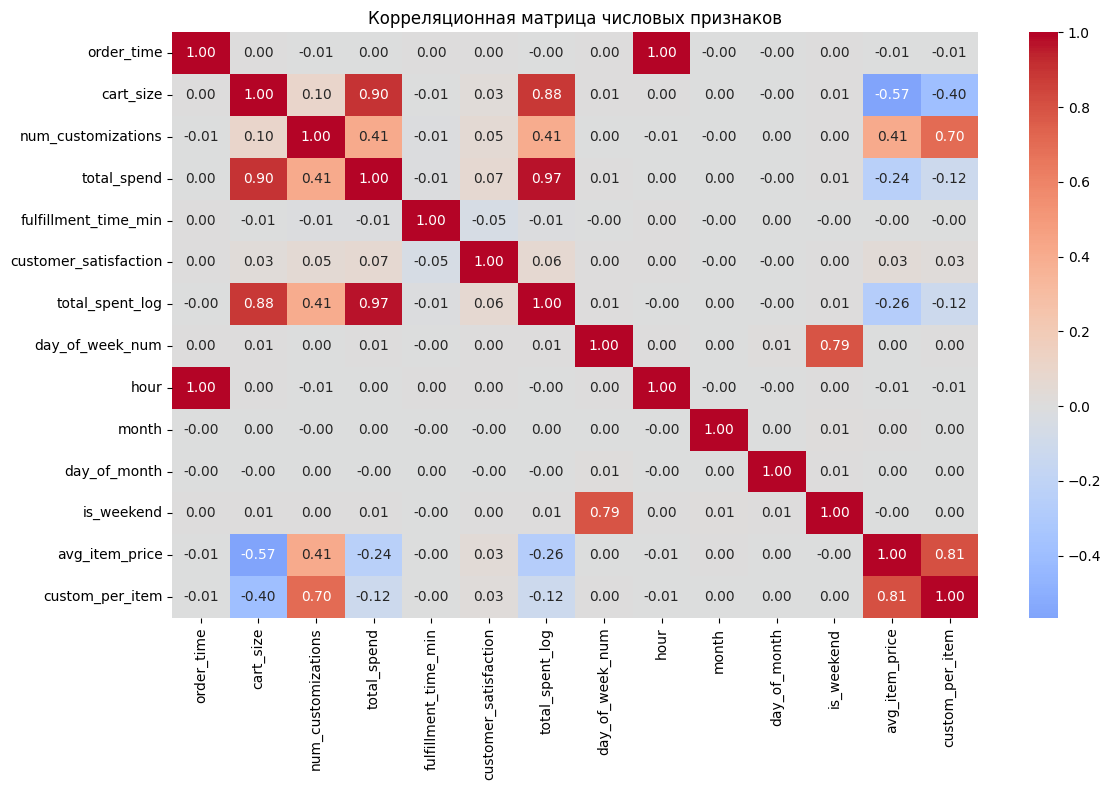

In [101]:
# Корреляционная матрица (только числовые)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig('../presentation/correlation_matrix.png', dpi=100)
plt.show()

In [102]:
# Удаление временных/вспомогательных столбцов
# Список столбцов, которые не нужно сохранять
cols_to_drop = []
# Если есть столбцы от предыдущих запусков, удаляем их
for col in ['minute', 'hour_from_time', 'time_period_temp', 'order_time']:
    if col in df.columns:
        cols_to_drop.append(col)


if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"Удалены столбцы: {cols_to_drop}")

# Сохранение очищенного датасета ----------
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_data.csv', index=False)
print(f"\nДатасет сохранён в 'data/processed/cleaned_data.csv'")
print(f"Итоговая размерность: {df.shape}")
print("Столбцы в сохранённом файле:")
print(df.columns.tolist())

Удалены столбцы: ['order_time']

Датасет сохранён в 'data/processed/cleaned_data.csv'
Итоговая размерность: (100000, 28)
Столбцы в сохранённом файле:
['customer_id', 'order_id', 'order_date', 'day_of_week', 'order_channel', 'store_id', 'store_location_type', 'region', 'customer_age_group', 'customer_gender', 'is_rewards_member', 'cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min', 'drink_category', 'has_food_item', 'order_ahead', 'customer_satisfaction', 'total_spent_log', 'day_of_week_num', 'hour', 'time_period', 'month', 'day_of_month', 'is_weekend', 'avg_item_price', 'custom_per_item']
